# GRM with PyMC — simulated dataset


## Model

$$
P(u_{ij} \geq k \mid \theta_i, a_j, b_{jk}) = \sigma\!\left(a_j(\theta_i - b_{jk})\right)
$$

Priors: $\theta_i \sim \mathcal{N}(0,1)$, $a_j \sim \text{LogNormal}(0, 0.5)$, $b_{jk} \sim \mathcal{N}(0,1.5)$ (ordered per item).

In [8]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import nest_asyncio
nest_asyncio.apply()

## Data

In [22]:
rng = np.random.default_rng(42)

N = 1000  # respondents
J = 20   # items total

# K per item
K_per_item = np.array([3] * 10 + [4] * 10)

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
# b_true[j]: sorted array of K_j-1 thresholds
b_true = [np.sort(rng.normal(0, 1, K_per_item[j] - 1)) for j in range(J)]

# Generate responses
Y = np.zeros((N, J), dtype=int)
for j in range(J):
    K_j = K_per_item[j]
    # P*(Y >= k) for k=1,...,K_j-1 — shape (N, K_j-1)
    eta = a_true[j] * (theta_true[:, None] - b_true[j][None, :])
    cum_p = 1 / (1 + np.exp(-eta))
    probs = np.concatenate([
        1 - cum_p[:, :1],
        cum_p[:, :-1] - cum_p[:, 1:],
        cum_p[:, -1:],
    ], axis=1)  # (N, K_j)
    u = rng.uniform(size=(N, 1))
    Y[:, j] = (u > np.cumsum(probs, axis=1)).sum(axis=1)

print(f"Response matrix shape: {Y.shape}")
for k in np.unique(K_per_item):
    items_k = np.where(K_per_item == k)[0]
    counts = np.bincount(Y[:, items_k].ravel(), minlength=k)
    print(f"K={k}: {len(items_k)} items, category counts = {counts}")

Response matrix shape: (1000, 20)
K=3: 10 items, category counts = [4266 1907 3827]
K=4: 10 items, category counts = [3856 1150 1420 3574]


In [23]:
df = pd.DataFrame(Y,
                  index=[f"person_{i+1}" for i in range(Y.shape[0])],
                  columns=[f"item_{j+1}" for j in range(Y.shape[1])])

df.tail()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,item_19,item_20
person_996,2,2,1,2,1,0,0,0,2,2,0,0,0,3,2,0,1,0,0,0
person_997,0,0,2,2,0,0,1,2,2,0,1,2,1,1,2,3,3,1,3,2
person_998,2,2,2,0,2,1,2,2,2,1,1,2,3,3,1,3,0,1,1,0
person_999,2,2,1,2,2,0,2,2,2,0,2,3,3,0,1,3,0,1,3,0
person_1000,2,2,2,2,1,0,2,2,2,2,3,3,3,2,2,0,0,0,3,3


In [24]:
df.to_csv("./data.csv", index=True)

## Preprocessing

In [25]:
df_long = pd.melt(
    df.reset_index(),
    id_vars="index",
    var_name="item",
    value_name="response",
).rename(columns={"index": "person"})

item_categories = df.columns
df_long["person"] = pd.Categorical(df_long["person"], categories=df.index, ordered=True)
df_long["item"] = pd.Categorical(df_long["item"], categories=item_categories, ordered=True)

df_long.head()

,person,item,response
0,person_1,item_1,2
1,person_2,item_1,0
2,person_3,item_1,0
3,person_4,item_1,2
4,person_5,item_1,0


In [26]:
import numpy as np
import pymc as pm

person_idx = df_long["person"].cat.codes.to_numpy()
persons = df_long["person"].cat.categories.to_numpy()
item_idx = df_long["item"].cat.codes.to_numpy()
items = df_long["item"].cat.categories.to_numpy()
responses = df_long["response"].to_numpy().astype("int64")

K = int(responses.max() + 1)
n_thresholds = K - 1

coords = {
    "person": persons,
    "item": items,
    "threshold": np.arange(n_thresholds),
    "obs_id": np.arange(len(df_long)),
}


## PyMC


In [27]:
K_per_item = df.max() + 1
unique_K = np.sort(np.unique(K_per_item))

with pm.Model() as grm_mixed:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, shape=N)
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, shape=J)

    for k in unique_K:
        item_idx = np.where(K_per_item == k)[0]
        J_k = len(item_idx)
        Y_k = Y[:, item_idx]  # (N, J_k)
        b_k = pm.Normal(
            f"b_{k}",
            mu=0.0,
            sigma=1.5,
            shape=(J_k, k - 1),
            transform=pm.distributions.transforms.ordered,
            initval=np.tile(np.linspace(-1.0, 1.0, k - 1), (J_k, 1)),
        )

        eta_k = theta[:, None] * a[item_idx][None, :]   # (N, J_k)
        cutpoints_k = pm.Deterministic(f"cutpoints_{k}", a[item_idx][:, None] * b_k)  # (J_k, K-1)

        pm.OrderedLogistic(
            f"y_{k}",
            eta=eta_k,
            cutpoints=cutpoints_k[item_idx],
            observed=Y_k,
        )

pm.model_to_graphviz(grm_mixed)

IndexError: index 10 is out of bounds for axis 0 with size 10
Apply node that caused the error: AdvancedSubtensor(cutpoints_4, [10 11 12 ... 17 18 19])
Toposort index: 19
Inputs types: [TensorType(float64, shape=(10, 3)), TensorType(int64, shape=(10,))]
Inputs shapes: [(10, 3), (10,)]
Inputs strides: [(24, 8), (8,)]
Inputs values: ['not shown', 'not shown']
Outputs clients: [[ExpandDims{axis=0}(AdvancedSubtensor.0)]]

Backtrace when the node is created (use PyTensor flag traceback__limit=N to make it longer):
  File "c:\Users\nigim\Desktop\grm-pymc-mirt\.venv\Lib\site-packages\ipykernel\zmqshell.py", line 663, in run_cell
    return super().run_cell(*args, **kwargs)
  File "c:\Users\nigim\Desktop\grm-pymc-mirt\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3170, in run_cell
    result = self._run_cell(
  File "c:\Users\nigim\Desktop\grm-pymc-mirt\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3225, in _run_cell
    result = runner(coro)
  File "c:\User

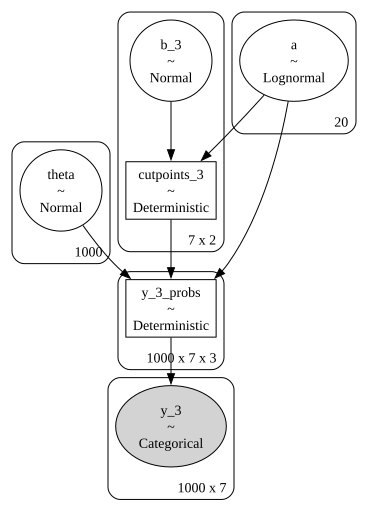

In [16]:
K_per_item = df.max() + 1
unique_K = np.sort(np.unique(K_per_item))

with pm.Model() as grm_mixed:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, shape=N)
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, shape=J)

    k = 3
    item_idx = np.where(K_per_item == k)[0]
    J_k = len(item_idx)
    Y_k = Y[:, item_idx]  # (N, J_k)
    b_k = pm.Normal(
        f"b_{k}",
        mu=0.0,
        sigma=1.5,
        shape=(J_k, k - 1),
        transform=pm.distributions.transforms.ordered,
        initval=np.tile(np.linspace(-1.0, 1.0, k - 1), (J_k, 1)),
    )

    eta_k = theta[:, None] * a[item_idx][None, :]   # (N, J_k)
    cutpoints_k = pm.Deterministic(f"cutpoints_{k}", a[item_idx][:, None] * b_k)  # (J_k, K-1)

    pm.OrderedLogistic(
        f"y_{k}",
        eta=eta_k,
        cutpoints=cutpoints_k[item_idx],
        observed=Y_k,
    )


pm.model_to_graphviz(grm_mixed)


In [28]:
with grm_mixed:
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        nuts_sampler="numpyro",
    )


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]





Running chain 0:   5%|▌         | 100/2000 [00:39<12:09,  2.60it/s]


Running chain 0:  10%|█         | 200/2000 [01:23<12:33,  2.39it/s]


Running chain 0:  15%|█▌        | 300/2000 [02:03<11:38,  2.43it/s]


Running chain 0:  20%|██        | 400/2000 [02:41<10:33,  2.53it/s]


Running chain 0:  25%|██▌       | 500/2000 [03:18<09:41,  2.58it/s]


Running chain 0:  30%|███       | 600/2000 [03:55<08:55,  2.61it/s]


Running chain 0:  35%|███▌      | 700/2000 [04:33<08:13,  2.64it/s]


Running chain 0:  40%|████      | 800/2000 [05:10<07:32,  2.65it/s]


Running chain 0:  45%|████▌     | 900/2000 [05:47<06:52,  2.66it/s]


Running chain 0:  50%|█████     | 1000/2000 [06:24<06:14,  2.67it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [07:01<05:35,  2.68it/s]


Running chain 0:  60%|██████    | 1200/2000 [07:38<04:57,  2.69it/s]


Running chain 0:  65%|██████▌   | 

In [29]:
summary = az.summary(
    idata,
    var_names=["a"],
    round_to=3,
)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.196,0.195,0.041,0.558,0.097,0.055,4.592,18.934,3.037
a[1],0.222,0.094,0.103,0.359,0.046,0.018,4.301,11.659,4.164
a[2],0.471,0.225,0.188,0.784,0.111,0.037,4.378,11.441,3.626
a[3],0.830,0.084,0.709,0.982,0.040,0.024,4.597,11.243,2.889
a[4],0.411,0.096,0.237,0.562,0.046,0.022,4.559,11.673,3.058
a[5],0.239,0.120,0.076,0.416,0.060,0.028,4.485,16.203,3.411
a[6],0.535,0.129,0.322,0.678,0.064,0.032,4.718,21.096,2.905
a[7],0.256,0.106,0.106,0.444,0.052,0.028,4.525,19.215,3.131
a[8],0.794,0.142,0.593,1.006,0.070,0.028,4.543,19.457,3.107
a[9],0.353,0.136,0.180,0.527,0.067,0.014,5.027,12.141,2.360


In [ ]:
summary = az.summary(
    idata,
    var_names=["a", "theta"] + [f"b_{k}" for k in unique_K],
    round_to=3,
)
bad = summary.query("r_hat > 1.01").copy()
bad["kind"] = bad.index.to_series().str.extract(r"^([a-zA-Z_]+)")[0]
bad.groupby("kind")["r_hat"].agg(["count", "max", "mean"])

In [ ]:
a_mean = idata.posterior["a"].mean(dim=["chain", "draw"]).values  # (J,)
b_mean = idata.posterior["b"].mean(dim=["chain", "draw"]).values  # (J, K-1)


In [ ]:
import os
os.makedirs("./results", exist_ok=True)

a_mean = idata.posterior["a"].mean(dim=["chain", "draw"]).values  # (J,)
b_mean = idata.posterior["b"].mean(dim=["chain", "draw"]).values  # (J, K-1)

rows = []
for j in range(len(df.columns)):
    row = {"item": df.columns[j], "a": a_mean[j]}
    for k in range(K - 1):
        row[f"b{k+1}"] = b_mean[j, k]
    rows.append(row)

pymc_params = pd.DataFrame(rows)
display(pymc_params)

pymc_params.to_csv("./results/pymc_params.csv", index=False)
print("Saved to ./results/pymc_params.csv")


In [ ]:
theta_mean = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
theta_df = pd.DataFrame({"person": np.arange(N), "theta": theta_mean})
display(theta_df.head())

theta_df.to_csv("./results/pymc_theta.csv", index=False)
print("Saved to ./results/pymc_theta.csv")